# Prompt U-Net Version 292 Training

# Changes

## 1. Preprocessing

- **Isotropic resampling before normalization**
  - Apply once to volumes before data generation.

- **Data loader**
  - The training data loaders have been completely rewritten for .npz usage.

- **Volume standardization**
  - Switch to **z-score normalization**
  - Apply on the full volume.

- **Important design choice**
  - CT and MRI use different normalization pipelines.
  - CT or MRT is stored in `.npz` files.

---

## 2. CT Preprocessing

1. **Intensity clipping**
   - Range: `[-1000, 1000]`
   - Removes extreme artifacts (e.g., metal).

2. **Global statistics (hardcoded)**
   - Mean: `-15`
   - Std: `160`

3. **Normalization**
   - Apply z-score normalization.

---

## 3. MRI Preprocessing

*(MRI intensities have no physical unit)*

1. **Percentile clipping**
   - Applied on foreground only (`> 0`)
   - Range: 0.5% – 99.5%

2. **Statistics computation**
   - Mean and std computed from the volume (foreground only)

3. **Normalization**
   - Apply z-score normalization.

---

## 4. Data Generator

- Normalization must be applied **inside datagen**
  - Required because original (unnormalized) volumes are needed for `nnInteractive`

- Issue:
  - Resampling inside datagen breaks isotropy again
  - `_extract_patch_2d()` always extracts fixed `128 × 128` patches

- Fixes / changes:
  - Cache normalization results
  - Remove volume cropping completely
  - Ignore samples where any axis is below a threshold
    - Prevents distorted ("squashed") images (e.g. `192 × 192 × 10`)
  - If a dimension `< 128`, apply padding with value **5 instead of 0**
    - Reason: `0` would represent tissue after normalization

- Data format per sample:
  - `(x[num_dp,128,128,1], y[num_dp,128,128,1], p[num_dp,128,128,2], m)`
  - where `m = modality`

---

## 5. Performance Issues

- Datagen caused **OOM (out-of-memory) errors during training**
  - Entire datagen pipeline switched to **NumPy implementation**

---

## 6. Data Augmentation

- MRI:
  - Reduced noise strength

- CT:
  - No noise augmentation
  - No gamma augmentation

- General changes:
  - Stronger random brightness augmentation
  - Geometric augmentation probability reduced to **85%**
    - Previously: 100%

---

## 7. Codebase Restructuring

- Model, optimizer, and augmentation moved to `.py` files
- `train.py` added
- Notebook (`.ipynb`) structure temporarily retained

## Setup

In [2]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

tf.keras.mixed_precision.set_global_policy("mixed_float16")

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-04-15 11:26:36.204323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776245196.223832      73 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776245196.229827      73 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776245196.246079      73 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776245196.246112      73 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776245196.246128      73 computation_placer.cc:177] computation placer alr

TF  : 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from prompt_unet_292 import PromptUNet
from prompt_unet_292_optimizer import PromptUNetOptimizer

## Data Loading

In [4]:
dataset_paths = [
    "data/train_data/nako_combined.npz",
    "data/train_data/total_seg_combined.npz",
    "data/train_data/msd_combined.npz",
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.

Image size: 128 x 128


## Hyperparameters

In [5]:
version           = "p_unet_292"

epochs            = 4000
batch_size        = 128
dp_training       = 3500
dp_testing        = 1000

offset            = 12
max_number_labels = 4

new_ds       = 75    # refresh training data every N epochs
new_val_loop = 300   # run validation every N epochs

## Model & Optimizer

In [6]:
opt_config = PromptUNetOptimizer(
    epochs               = epochs,
    batch_size           = batch_size,
    dp_training          = dp_training,
    warmup_epochs         = 50,
    initial_learning_rate = 1e-6,
    warmup_target         = 1e-3,
    alpha                 = 0.01,
)

model = PromptUNet(height=datagenerator.height, width=datagenerator.width)
model.optimizer = opt_config.get_optimizer()

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

I0000 00:00:1776245417.945209      73 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1776245420.464703      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


Trainable params: 4,062,556


## Augmentation Pipeline

In [7]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.45,
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.85,
    prob_morph             = 0.60,
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time, eliminating the OOM risk.

In [8]:
# ── Shared numpy buffer ───────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality (0=CT 1=MRI)
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

Epoch   10  loss: 0.307864
Epoch   11  loss: 0.281089
Epoch   12  loss: 0.261853
Epoch   13  loss: 0.248271
Epoch   14  loss: 0.236517
Epoch   15  loss: 0.227715


2026-04-15 11:41:56.960300: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   16  loss: 0.221176
Epoch   17  loss: 0.215647
Epoch   18  loss: 0.206465
Epoch   19  loss: 0.200699
Epoch   20  loss: 0.197859
Epoch   21  loss: 0.189958
Epoch   22  loss: 0.185570
Epoch   23  loss: 0.181714
Epoch   24  loss: 0.179090
Epoch   25  loss: 0.176568
Epoch   26  loss: 0.171224
Epoch   27  loss: 0.168198
Epoch   28  loss: 0.165301
Epoch   29  loss: 0.164416
Epoch   30  loss: 0.160576
Epoch   31  loss: 0.158426


2026-04-15 11:45:23.869862: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   32  loss: 0.159820
Epoch   33  loss: 0.158821
Epoch   34  loss: 0.157677
Epoch   35  loss: 0.152938
Epoch   36  loss: 0.152344
Epoch   37  loss: 0.152747
Epoch   38  loss: 0.146339
Epoch   39  loss: 0.145584
Epoch   40  loss: 0.143232
Epoch   41  loss: 0.141909
Epoch   42  loss: 0.138399
Epoch   43  loss: 0.135890
Epoch   44  loss: 0.133538
Epoch   45  loss: 0.132451
Epoch   46  loss: 0.132557
Epoch   47  loss: 0.126851
Epoch   48  loss: 0.124953
Epoch   49  loss: 0.123196
Epoch   50  loss: 0.121453
Epoch   51  loss: 0.119424
Epoch   52  loss: 0.118502
Epoch   53  loss: 0.115311
Epoch   54  loss: 0.115949
Epoch   55  loss: 0.116765
Epoch   56  loss: 0.114078
Epoch   57  loss: 0.116740
Epoch   58  loss: 0.112774
Epoch   59  loss: 0.111446
Epoch   60  loss: 0.111126
Epoch   61  loss: 0.109852
Epoch   62  loss: 0.107470
Epoch   63  loss: 0.108434


2026-04-15 11:52:18.471716: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   64  loss: 0.107257
Epoch   65  loss: 0.106196
Epoch   66  loss: 0.107500
Epoch   67  loss: 0.106291
Epoch   68  loss: 0.107946
Epoch   69  loss: 0.107333
Epoch   70  loss: 0.106232
Epoch   71  loss: 0.103863
Epoch   72  loss: 0.104700
Epoch   73  loss: 0.103591
Epoch   74  loss: 0.102358
Epoch   75  loss: 0.101945


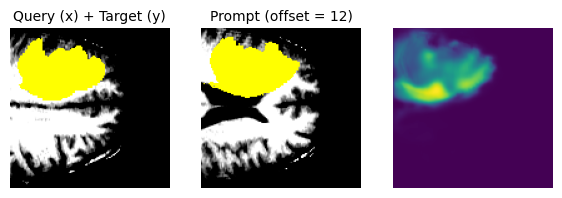

Creating new Data Points ...
It took 119 seconds
Epoch   76  loss: 0.109443
Epoch   77  loss: 0.106813
Epoch   78  loss: 0.104927
Epoch   79  loss: 0.104903
Epoch   80  loss: 0.102744
Epoch   81  loss: 0.101753
Epoch   82  loss: 0.101608
Epoch   83  loss: 0.099440
Epoch   84  loss: 0.098283
Epoch   85  loss: 0.098257
Epoch   86  loss: 0.098108
Epoch   87  loss: 0.096715
Epoch   88  loss: 0.097265
Epoch   89  loss: 0.096373
Epoch   90  loss: 0.096397
Epoch   91  loss: 0.096519
Epoch   92  loss: 0.097489
Epoch   93  loss: 0.095635
Epoch   94  loss: 0.096141
Epoch   95  loss: 0.094953
Epoch   96  loss: 0.094774
Epoch   97  loss: 0.093724
Epoch   98  loss: 0.091598
Epoch   99  loss: 0.092736
Epoch  100  loss: 0.090976
Epoch  101  loss: 0.091354
Epoch  102  loss: 0.091176
Epoch  103  loss: 0.092161
Epoch  104  loss: 0.092335
Epoch  105  loss: 0.091841
Epoch  106  loss: 0.090412
Epoch  107  loss: 0.089696
Epoch  108  loss: 0.090498
Epoch  109  loss: 0.089149
Epoch  110  loss: 0.089249
Epoch 

2026-04-15 12:10:29.327233: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  128  loss: 0.083379
Epoch  129  loss: 0.084945
Epoch  130  loss: 0.083608
Epoch  131  loss: 0.084522
Epoch  132  loss: 0.082177
Epoch  133  loss: 0.081690
Epoch  134  loss: 0.082225
Epoch  135  loss: 0.083120
Epoch  136  loss: 0.081218
Epoch  137  loss: 0.080924
Epoch  138  loss: 0.081411
Epoch  139  loss: 0.080922
Epoch  140  loss: 0.081069
Epoch  141  loss: 0.080765
Epoch  142  loss: 0.080729
Epoch  143  loss: 0.078657
Epoch  144  loss: 0.079770
Epoch  145  loss: 0.079539
Epoch  146  loss: 0.078838
Epoch  147  loss: 0.077592
Epoch  148  loss: 0.077086
Epoch  149  loss: 0.077771
Epoch  150  loss: 0.078564


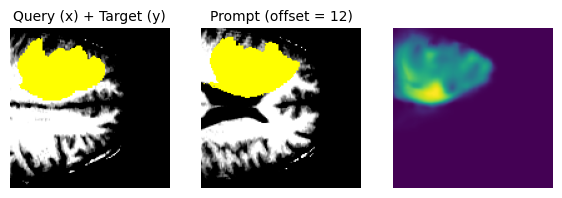

Creating new Data Points ...
It took 85 seconds
Epoch  151  loss: 0.085454
Epoch  152  loss: 0.081049
Epoch  153  loss: 0.079245
Epoch  154  loss: 0.077583
Epoch  155  loss: 0.078087
Epoch  156  loss: 0.076483
Epoch  157  loss: 0.076346
Epoch  158  loss: 0.075537
Epoch  159  loss: 0.075470
Epoch  160  loss: 0.073987
Epoch  161  loss: 0.072838
Epoch  162  loss: 0.073070
Epoch  163  loss: 0.073002
Epoch  164  loss: 0.072042
Epoch  165  loss: 0.071169
Epoch  166  loss: 0.072953
Epoch  167  loss: 0.069867
Epoch  168  loss: 0.069854
Epoch  169  loss: 0.069638
Epoch  170  loss: 0.068331
Epoch  171  loss: 0.068598
Epoch  172  loss: 0.070289
Epoch  173  loss: 0.069734
Epoch  174  loss: 0.067788
Epoch  175  loss: 0.067331
Epoch  176  loss: 0.067062
Epoch  177  loss: 0.067847
Epoch  178  loss: 0.066448
Epoch  179  loss: 0.065965
Epoch  180  loss: 0.066105
Epoch  181  loss: 0.067576
Epoch  182  loss: 0.066584
Epoch  183  loss: 0.065555
Epoch  184  loss: 0.064761
Epoch  185  loss: 0.063923
Epoch  

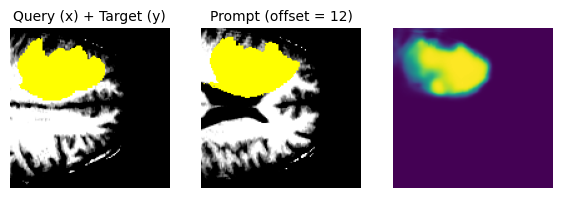

Creating new Data Points ...
It took 194 seconds
Epoch  226  loss: 0.119142
Epoch  227  loss: 0.106541
Epoch  228  loss: 0.103553
Epoch  229  loss: 0.101540
Epoch  230  loss: 0.097899
Epoch  231  loss: 0.098189
Epoch  232  loss: 0.095533
Epoch  233  loss: 0.094228
Epoch  234  loss: 0.092624
Epoch  235  loss: 0.092429
Epoch  236  loss: 0.090923
Epoch  237  loss: 0.092204
Epoch  238  loss: 0.090651
Epoch  239  loss: 0.091084
Epoch  240  loss: 0.088726
Epoch  241  loss: 0.086759
Epoch  242  loss: 0.089597
Epoch  243  loss: 0.085255
Epoch  244  loss: 0.085374
Epoch  245  loss: 0.084802
Epoch  246  loss: 0.083881
Epoch  247  loss: 0.084721


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
        })

        # ── Validation dataset (built once, no augmentation) ───────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ─────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch (dataset is already mapped/batched/prefetched)
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)